# GOTISHEEL TECHNOLOGIES TASK-1

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

In [16]:
df = pd.read_csv("industrial_safety_events_dataset_updated.csv")


In [17]:
df.head()

,_id,client_id,id,camera,frame_time,snapshot_frame_time,snapshot_box_x1,snapshot_box_y1,snapshot_box_x2,snapshot_box_y2,...,entered_zones,has_clip,has_snapshot,location,zone,unit,created_at,status,remarks,__v
0,da1085fc742f82bdb2b8a4cd,961fd31c1ff972695600243b,2a921df4-369f-4fb0-b0c0-d3395a53e780,cam_0649,1.779766e+09,1.779766e+09,599,517,328,98,...,Assembly Zone,True,True,225fb0cc08d8ab58420e0c49,Boiler Room,Unit-C,2026-05-26T03:34:55.501645,in_progress,Immediate action required,0
1,53c938e5983dfed2b0d84ea3,7a0e6d9a941282c9823915c6,3a957c3a-879d-4d82-b118-51f314be8b03,cam_0239,1.778639e+09,1.778639e+09,442,228,305,443,...,Packing Unit,True,True,c21bbab58512e438af261807,Boiler Room,Unit-B,2026-05-13T02:23:57.474869,in_progress,Worker warned,0
2,6a42413a4195f2f60abbbea5,732c853a16d54d49afadb6ca,102745a9-2ab6-489a-aa3e-4c514de21d97,cam_0581,1.778948e+09,1.778948e+09,1076,62,224,625,...,Warehouse,True,True,1df6303fe935f10cfc4a91ad,Packing Unit,Unit-A,2026-05-16T16:10:44.522125,open,False positive reviewed,0
3,2c59a8e119739deafdf87417,4b293e325a55544d251c4084,7968224f-d83e-48c8-9b81-fa840b533f6a,cam_0046,1.778929e+09,1.778929e+09,255,21,746,700,...,Packing Unit,True,True,84e1b815bf2dbbd48b683be2,Boiler Room,Unit-C,2026-05-16T10:49:24.502204,open,Immediate action required,0
4,c5da3c1c7d54155ae0256eab,18f58eeeb785d74d0f0e796c,e6b87565-3081-43c5-832b-b9e5dd345f91,cam_0390,1.779522e+09,1.779522e+09,395,614,965,435,...,Boiler Room,True,True,da42a9445abda1e6fffe365d,Warehouse,Unit-C,2026-05-23T07:38:35.498098,open,Escalated to safety team,0


In [18]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (3500, 47)


In [19]:
df.columns

Index(['_id', 'client_id', 'id', 'camera', 'frame_time', 'snapshot_frame_time',
       'snapshot_box_x1', 'snapshot_box_y1', 'snapshot_box_x2',
       'snapshot_box_y2', 'snapshot_area', 'snapshot_region_x1',
       'snapshot_region_y1', 'snapshot_region_x2', 'snapshot_region_y2',
       'snapshot_score', 'label', 'sub_label', 'top_score', 'false_positive',
       'start_time', 'end_time', 'score', 'box_x1', 'box_y1', 'box_x2',
       'box_y2', 'area', 'ratio', 'region_x1', 'region_y1', 'region_x2',
       'region_y2', 'stationary', 'motionless_count', 'position_changes',
       'current_zones', 'entered_zones', 'has_clip', 'has_snapshot',
       'location', 'zone', 'unit', 'created_at', 'status', 'remarks', '__v'],
      dtype='object')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 47 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   _id                  3500 non-null   object 
 1   client_id            3500 non-null   object 
 2   id                   3500 non-null   object 
 3   camera               3500 non-null   object 
 4   frame_time           3500 non-null   float64
 5   snapshot_frame_time  3500 non-null   float64
 6   snapshot_box_x1      3500 non-null   int64  
 7   snapshot_box_y1      3500 non-null   int64  
 8   snapshot_box_x2      3500 non-null   int64  
 9   snapshot_box_y2      3500 non-null   int64  
 10  snapshot_area        3500 non-null   int64  
 11  snapshot_region_x1   3500 non-null   int64  
 12  snapshot_region_y1   3500 non-null   int64  
 13  snapshot_region_x2   3500 non-null   int64  
 14  snapshot_region_y2   3500 non-null   int64  
 15  snapshot_score       3500 non-null   f

In [21]:
df.isnull().sum()

_id                       0
client_id                 0
id                        0
camera                    0
frame_time                0
snapshot_frame_time       0
snapshot_box_x1           0
snapshot_box_y1           0
snapshot_box_x2           0
snapshot_box_y2           0
snapshot_area             0
snapshot_region_x1        0
snapshot_region_y1        0
snapshot_region_x2        0
snapshot_region_y2        0
snapshot_score            0
label                     0
sub_label              3500
top_score                 0
false_positive            0
start_time                0
end_time                  0
score                     0
box_x1                    0
box_y1                    0
box_x2                    0
box_y2                    0
area                      0
ratio                     0
region_x1                 0
region_y1                 0
region_x2                 0
region_y2                 0
stationary                0
motionless_count          0
position_changes    

In [22]:
df['created_at'] = pd.to_datetime(df['created_at'])

In [23]:
print(df.shape)

print(df['camera'].nunique())

print(df['camera'].value_counts().head(10))

(3500, 47)
1000
camera
cam_0239    683
cam_0371    107
cam_0581     88
cam_0598     67
cam_0806     44
cam_0271     37
cam_0991     33
cam_0292     30
cam_0740     27
cam_0193     27
Name: count, dtype: int64


# MOST ACTIVE CAMERA

In [24]:
top_camera = df['camera'].value_counts().idxmax()

In [25]:
camera_event_count = df['camera'].value_counts().max()

print(
    f"Most active camera: {top_camera} "
    f"with {camera_event_count} events"
)

Most active camera: cam_0239 with 683 events


# CREATE KPI METRICS

In [26]:
total_events = len(df)

total_cameras = df['camera'].nunique()

total_zones = df['zone'].nunique()

total_labels = df['label'].nunique()

average_confidence = df['score'].mean()

print("Total Events:", total_events)
print("Total Cameras:", total_cameras)
print("Total Zones:", total_zones)
print("Total Labels:", total_labels)
print("Average Confidence:", round(average_confidence,2))

Total Events: 3500
Total Cameras: 1000
Total Zones: 6
Total Labels: 20
Average Confidence: 0.74


# EVENT DISTRIBUTION ANALYSIS

In [27]:
label_counts = df['label'].value_counts()

label_counts

label
without_glove      213
smoke              211
without_goggle     209
loitering          195
license_plate      192
without_helmet     189
nomask             187
crowd              182
no_ifr             181
fall               177
fire               169
no_harness         166
nohairnet          165
cell_phone         162
smoker             161
without_boot       156
hairnet            151
person             149
no_extinguisher    143
mask               142
Name: count, dtype: int64

In [28]:
fig = px.bar(
    x=label_counts.index,
    y=label_counts.values,
    title="Event Count Per Label",
    labels={
        'x':'Violation Type',
        'y':'Count'
    },
    color=label_counts.values
)

fig.show()

# PIE CHART OF VIOLATIONS

In [29]:
fig = px.pie(
    values=label_counts.values,
    names=label_counts.index,
    title="Violation Distribution"
)

fig.show()

# CAMERA-WISE VIOLATIONS

In [30]:
camera_counts = df['camera'].value_counts().head(10)

camera_counts

camera
cam_0239    683
cam_0371    107
cam_0581     88
cam_0598     67
cam_0806     44
cam_0271     37
cam_0991     33
cam_0292     30
cam_0740     27
cam_0193     27
Name: count, dtype: int64

In [31]:
fig = px.bar(
    x=camera_counts.index,
    y=camera_counts.values,
    title="Top 10 Cameras with Maximum Violations",
    labels={
        'x':'Camera',
        'y':'Violations'
    },
    color=camera_counts.values
)

fig.show()

# ZONE-WISE INCIDENTS

In [32]:
zone_counts = df['zone'].value_counts()

zone_counts

zone
Warehouse        687
Loading Bay      579
Packing Unit     568
Boiler Room      563
Assembly Zone    555
Control Room     548
Name: count, dtype: int64

In [33]:
fig = px.bar(
    x=zone_counts.index,
    y=zone_counts.values,
    title="Zone-wise Incidents",
    color=zone_counts.values
)

fig.show()

# EVENT TREND OVER TIME

In [34]:
daily_events = df.groupby(df['created_at'].dt.date).size()

daily_events

created_at
2026-04-26     38
2026-04-27    105
2026-04-28    166
2026-04-29    105
2026-04-30    128
2026-05-01    135
2026-05-02    105
2026-05-03    131
2026-05-04     97
2026-05-05    121
2026-05-06    124
2026-05-07    112
2026-05-08    129
2026-05-09    125
2026-05-10    105
2026-05-11    123
2026-05-12    157
2026-05-13    101
2026-05-14    133
2026-05-15    125
2026-05-16     96
2026-05-17    113
2026-05-18     69
2026-05-19     96
2026-05-20    142
2026-05-21    106
2026-05-22    115
2026-05-23     97
2026-05-24    132
2026-05-25     98
2026-05-26     71
dtype: int64

In [35]:
fig = px.line(
    x=daily_events.index,
    y=daily_events.values,
    title="Daily Event Trend"
)

fig.show()

# HOURLY ANALYSIS

In [36]:
df['hour'] = df['created_at'].dt.hour

In [37]:
hourly_events = df.groupby('hour').size()

hourly_events

hour
0     144
1     118
2     153
3     186
4     160
5     160
6     110
7     175
8     149
9     138
10    139
11    157
12    146
13    151
14    154
15    139
16    159
17     99
18    146
19    159
20    113
21    147
22    144
23    154
dtype: int64

In [38]:
fig = px.line(
    x=hourly_events.index,
    y=hourly_events.values,
    title="Hourly Violation Trend",
    labels={
        'x':'Hour',
        'y':'Events'
    }
)

fig.show()

# SAFETY COMPLIANCE ANALYSIS

In [39]:
safe_labels = ['mask', 'hairnet', 'person']

df['compliance'] = df['label'].apply(
    lambda x: 'Compliant' if x in safe_labels else 'Violation'
)

In [40]:
compliance_counts = df['compliance'].value_counts()

compliance_counts

compliance
Violation    3058
Compliant     442
Name: count, dtype: int64

In [41]:
fig = px.pie(
    values=compliance_counts.values,
    names=compliance_counts.index,
    title="Safety Compliance Percentage"
)

fig.show()

# HIGH RISK EVENTS

In [42]:
high_risk = df[
    df['label'].isin(['fire', 'smoke', 'fall'])
]

In [43]:
high_risk['label'].value_counts()

label
smoke    211
fall     177
fire     169
Name: count, dtype: int64

In [44]:
risk_counts = high_risk['label'].value_counts()

fig = px.bar(
    x=risk_counts.index,
    y=risk_counts.values,
    title="High Risk Safety Events",
    color=risk_counts.values
)

fig.show()

# CORRELATION HEATMAP

In [45]:
numeric_cols = [
    'score',
    'top_score',
    'motionless_count',
    'position_changes',
    'area'
]

In [46]:
corr = df[numeric_cols].corr()

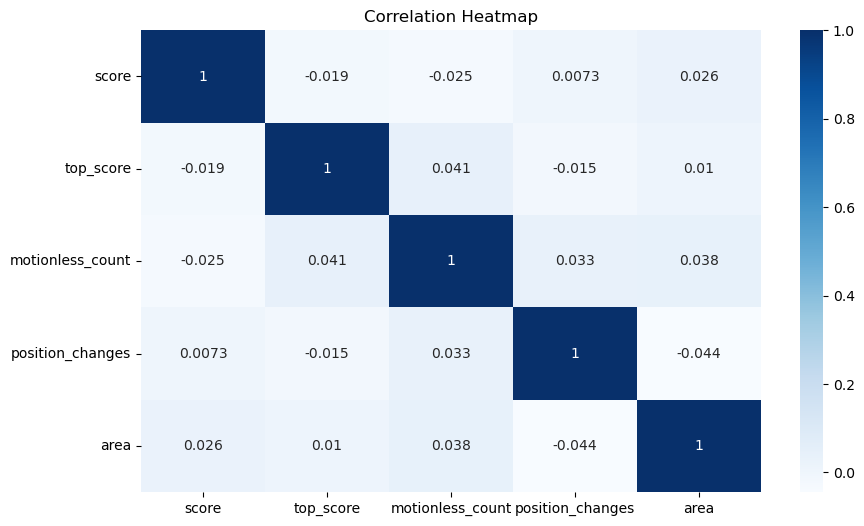

In [47]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Heatmap")

plt.show()

# MOST RECURRING VIOLATION

In [48]:
most_common_violation = df['label'].value_counts().idxmax()

count = df['label'].value_counts().max()

print("Most Recurring Violation:", most_common_violation)
print("Count:", count)

Most Recurring Violation: without_glove
Count: 213


# CAMERA WITH MAXIMUM VIOLATIONS

In [49]:
top_camera = df['camera'].value_counts().idxmax()

camera_count = df['camera'].value_counts().max()

print("Camera with Maximum Violations:", top_camera)
print("Violation Count:", camera_count)

Camera with Maximum Violations: cam_0239
Violation Count: 683


# MOST UNSAFE ZONE

In [50]:
top_zone = df['zone'].value_counts().idxmax()

zone_count = df['zone'].value_counts().max()

print("Most Unsafe Zone:", top_zone)
print("Incident Count:", zone_count)

Most Unsafe Zone: Warehouse
Incident Count: 687


# PEAK VIOLATION HOUR

In [51]:
peak_hour = df['hour'].value_counts().idxmax()

peak_count = df['hour'].value_counts().max()

print("Peak Violation Hour:", peak_hour)
print("Event Count:", peak_count)

Peak Violation Hour: 3
Event Count: 186


# FIRE & SMOKE ANALYSIS

In [52]:
fire_smoke = df[df['label'].isin(['fire', 'smoke'])]

print("Total Fire/Smoke Events:", len(fire_smoke))

print(fire_smoke['label'].value_counts())

Total Fire/Smoke Events: 380
label
smoke    211
fire     169
Name: count, dtype: int64


# PROFESSIONAL ANALYTICS VISUALS + BUSINESS INSIGHTS

In [53]:
false_positive_counts = df['false_positive'].value_counts()

false_positive_counts

false_positive
True     1819
False    1681
Name: count, dtype: int64

In [54]:
fig = px.pie(
    values=false_positive_counts.values,
    names=false_positive_counts.index,
    title="False Positive Analysis"
)

fig.show()

In [55]:
fig = px.histogram(
    df,
    x='score',
    nbins=30,
    title='Detection Confidence Score Distribution'
)

fig.show()

In [56]:
df['event_duration'] = df['end_time'] - df['start_time']

In [57]:
fig = px.box(
    df,
    y='event_duration',
    title='Event Duration Analysis'
)

fig.show()

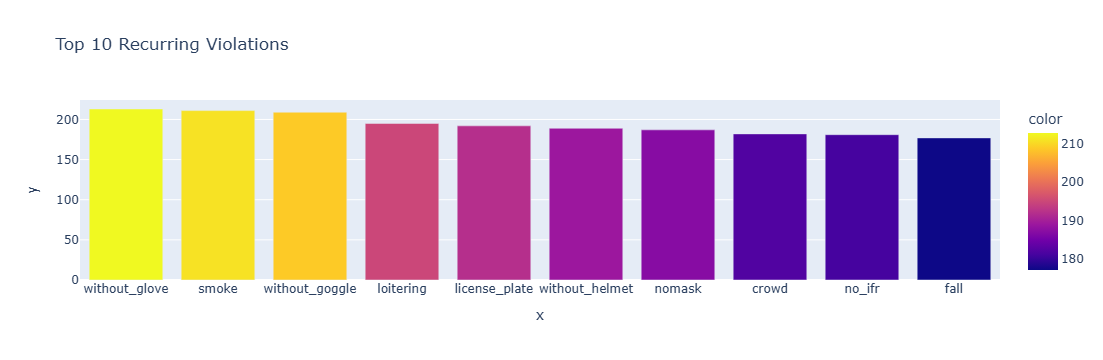

In [58]:
top_violations = df['label'].value_counts().head(10)

fig = px.bar(
    x=top_violations.index,
    y=top_violations.values,
    title='Top 10 Recurring Violations',
    color=top_violations.values
)

fig.show()

In [59]:
fig = px.scatter(
    df,
    x='motionless_count',
    y='position_changes',
    color='label',
    title='Motion vs Position Change Analysis'
)

fig.show()

In [60]:
unsafe_cameras = df['camera'].value_counts().reset_index()

unsafe_cameras.columns = ['Camera', 'Violations']

unsafe_cameras.head(10)

,Camera,Violations
0,cam_0239,683
1,cam_0371,107
2,cam_0581,88
3,cam_0598,67
4,cam_0806,44
5,cam_0271,37
6,cam_0991,33
7,cam_0292,30
8,cam_0740,27
9,cam_0193,27


In [61]:
unsafe_zones = df['zone'].value_counts().reset_index()

unsafe_zones.columns = ['Zone', 'Incidents']

unsafe_zones.head()

,Zone,Incidents
0,Warehouse,687
1,Loading Bay,579
2,Packing Unit,568
3,Boiler Room,563
4,Assembly Zone,555


# Key Business Insights

- The dataset contains surveillance events across multiple cameras and industrial zones.

- PPE-related violations were among the most frequently detected incidents.

- Certain cameras consistently captured higher unsafe activity, indicating high-risk monitoring areas.

- Violation activity showed hourly peaks, helping identify unsafe operational periods.

- Fire and smoke incidents were lower in frequency but categorized as critical-risk events.

- Detection confidence scores remained consistently high across most surveillance events.

# Industrial Safety Surveillance Analytics

This project analyzes industrial surveillance event data generated from an AI-based safety monitoring system. The analysis focuses on violation trends, compliance monitoring, camera analytics, zone-based risk assessment, and operational safety insights.